In [1]:
# load imports
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# load data with xarray
ds_radio = xr.open_dataset('radiometer.nc')
ds_radio = ds_radio[['vap', 'qc_vap']]

ds_mfrs = xr.open_dataset('mfrs.nc')
ds_mfrs

<xarray.Dataset> Size: 50MB
Dimensions:                                  (time: 1573879)
Coordinates:
  * time                                     (time) datetime64[ns] 13MB 2025-...
Data variables:
    direct_normal_narrowband_filter6         (time) float32 6MB ...
    qc_direct_normal_narrowband_filter6      (time) int32 6MB ...
    hemisp_narrowband_filter6                (time) float32 6MB ...
    qc_hemisp_narrowband_filter6             (time) int32 6MB ...
    direct_horizontal_narrowband_filter6     (time) float32 6MB ...
    qc_direct_horizontal_narrowband_filter6  (time) int32 6MB ...
Attributes: (12/38)
    command_line:                mfrsr7nch_ingest -s sgp -f C1
    Conventions:                 ARM-1.2
    process_version:             ingest-mfrsr7nch-1.8-0.el7
    dod_version:                 mfrsr7nch-b1-1.1
    input_source:                /data/collection/sgp/sgpmfrsr7nchC1.00/MFRSR...
    site_id:                     sgp
    ...                          ...
    doi:                         10.5439/1429369
    history:                     created by user dsmgr on machine prod-proc3....
    _file_dates:                 ['20250101', '20250102', '20250103', '202501...
    _file_times:                 ['070000', '070000', '070000', '070000', '07...
    _datastream:                 sgpmfrsr7nchC1.b1
    _arm_standards_flag:         1

In [3]:
# remove data where the value of the QC bit is not 0 (remove the bad data)
ds_mfrs = ds_mfrs.where(ds_mfrs.qc_direct_normal_narrowband_filter6 == 0, drop=True)
ds_mfrs = ds_mfrs.where(ds_mfrs.qc_hemisp_narrowband_filter6 == 0, drop=True)
ds_mfrs = ds_mfrs.where(ds_mfrs.qc_direct_horizontal_narrowband_filter6 == 0, drop=True)

ds_radio = ds_radio.where(ds_radio.qc_vap == 0, drop=True)

In [4]:
# create time mask where times match between the datasets
radio_time = ds_radio.time.values
mfrs_time = ds_mfrs.time.values

mask1 = np.isin(radio_time, mfrs_time)
mask2 = np.isin(mfrs_time, radio_time)

In [5]:
ds_combined = xr.merge([ds_radio, ds_mfrs], join='inner')
ds_combined

<xarray.Dataset> Size: 19MB
Dimensions:                                  (time: 342646)
Coordinates:
  * time                                     (time) datetime64[ns] 3MB 2025-0...
Data variables:
    vap                                      (time) float32 1MB 0.672 ... 0.994
    qc_vap                                   (time) float64 3MB 0.0 0.0 ... 0.0
    direct_normal_narrowband_filter6         (time) float32 1MB -0.0 ... -0.0
    qc_direct_normal_narrowband_filter6      (time) float64 3MB 0.0 0.0 ... 0.0
    hemisp_narrowband_filter6                (time) float32 1MB 0.001352 ... ...
    qc_hemisp_narrowband_filter6             (time) float64 3MB 0.0 0.0 ... 0.0
    direct_horizontal_narrowband_filter6     (time) float32 1MB 0.0 ... 0.0
    qc_direct_horizontal_narrowband_filter6  (time) float64 3MB 0.0 0.0 ... 0.0
Attributes: (12/55)
    command_line:                       mwr_ingest -s sgp -f C1
    process_version:                    ingest-mwr-2.3-0.el7
    ingest_software:                    ingest-mwr-2.3-0.el7
    dod_version:                        mwrlos-b1-2.3
    site_id:                            sgp
    facility_id:                        C1: Lamont, Oklahoma
    ...                                 ...
    datastream:                         sgpmwrlosC1.b1
    history:                            created by user dsmgr on machine prod...
    _file_dates:                        ['20250101', '20250101', '20250102', ...
    _file_times:                        ['000000', '000040', '000020', '00000...
    _datastream:                        sgpmwrlosC1.b1
    _arm_standards_flag:                1

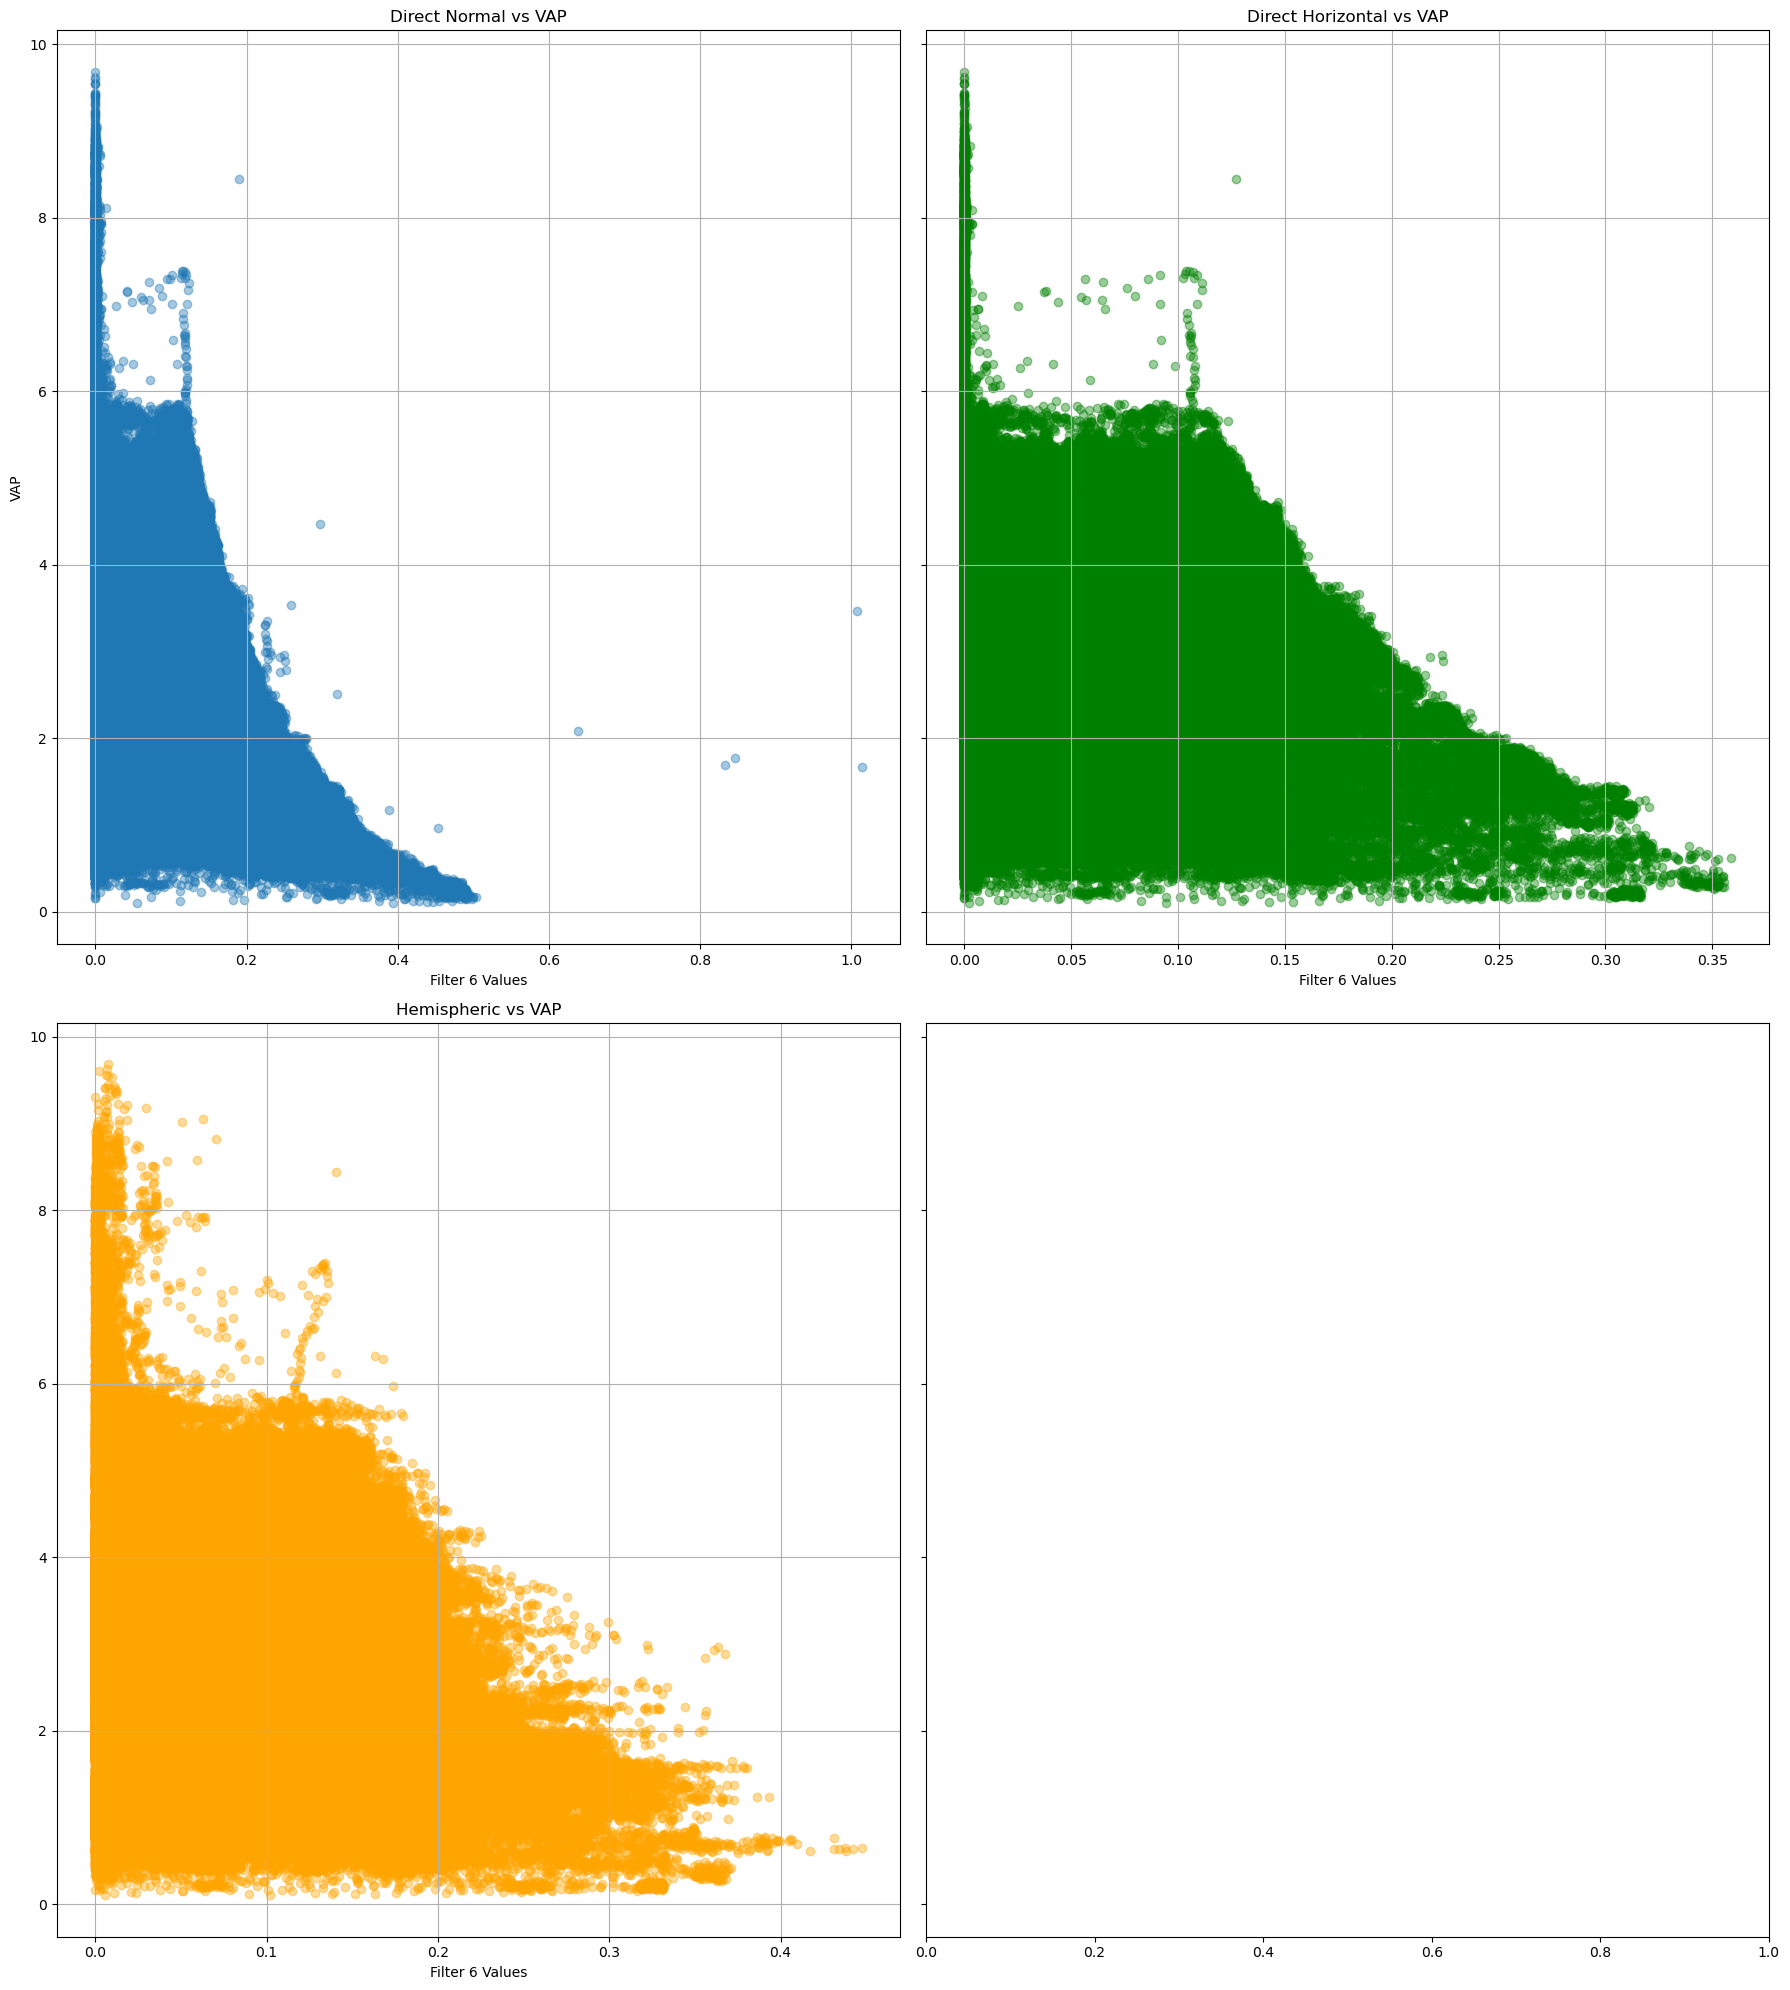

In [6]:
# Create a 1-row, 3-column plot layout
fig, axes = plt.subplots(2, 2, figsize=(18, 20), sharey=True)

# 1. Direct Normal
axes[0,0].scatter(ds_combined.direct_normal_narrowband_filter6.values, ds_combined.vap.values, alpha=0.4)
axes[0,0].set_title("Direct Normal vs VAP")
axes[0,0].set_xlabel("Filter 6 Values")
axes[0,0].set_ylabel("VAP")
axes[0,0].grid(True)

# 2. Hemispheric
axes[1,0].scatter(ds_combined.hemisp_narrowband_filter6.values, ds_combined.vap.values, alpha=0.4, color='orange')
axes[1,0].set_title("Hemispheric vs VAP")
axes[1,0].set_xlabel("Filter 6 Values")
axes[1,0].grid(True)

# 3. Direct Horizontal
axes[0,1].scatter(ds_combined.direct_horizontal_narrowband_filter6.values, ds_combined.vap.values, alpha=0.4, color='green')
axes[0,1].set_title("Direct Horizontal vs VAP")
axes[0,1].set_xlabel("Filter 6 Values")
axes[0,1].grid(True)

plt.tight_layout()
plt.show()

## Create the Model Dataset

In [7]:
# split the datasets into training, validation, and testing
x_data = ds_combined[['direct_normal_narrowband_filter6', 'hemisp_narrowband_filter6',
                      'direct_horizontal_narrowband_filter6']].to_array().values.T
y_data = ds_combined.vap.values / 10

x_train = x_data[:int(x_data.shape[0]*0.8),:]
x_val = x_data[int(x_data.shape[0]*0.8):int(x_data.shape[0]*0.9),:]
x_test = x_data[int(x_data.shape[0]*0.9):,:]

y_train = y_data[:int(x_data.shape[0]*0.8)]
y_val = y_data[int(x_data.shape[0]*0.8):int(x_data.shape[0]*0.9)]
y_test = y_data[int(x_data.shape[0]*0.9):]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(274116, 3) (274116,)
(34265, 3) (34265,)


In [8]:
# Target variables (y) must still be reshaped to (-1, 1) to match the output dimension
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("New Feature Shape:", X_train_tensor.shape)  # Should read: torch.Size([time, 3])
print("New Target Shape:", y_train_tensor.shape)    # Should read: torch.Size([time, 1])

# Rebuild your DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE, shuffle=False)

New Feature Shape: torch.Size([274116, 3])
New Target Shape: torch.Size([274116, 1])


In [9]:
# Initialize Model, Loss, and Optimizer
model = nn.Sequential(
    nn.Linear(3, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.MSELoss()  # Built-in softmax + negative log-likelihood
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)           # outputs shape will naturally be (64, 1)
        loss = criterion(outputs, batch_y)  # batch_y shape is (64, 1)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train MSE: {epoch_train_loss:.4f}")
    
    # --- VALIDATION PHASE ---
    model.eval()  # Sets the model to evaluation mode (turns off dropout/batchnorm)
    running_val_loss = 0.0
    
    with torch.no_grad():  # Disables gradient calculation to save memory and speed up
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# 4. Final Testing Phase
model.eval()

# CRITICAL FIX: All 3 tracking containers must be initialized before the loop!
total_absolute_error = 0.0  
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        
        # 1. Accumulate absolute errors for MAE
        absolute_errors = torch.abs(predictions - batch_y)
        total_absolute_error += absolute_errors.sum().item()
        
        # 2. Append the batch values to our lists for R²
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

average_mae = total_absolute_error / len(test_loader.dataset)
test_r2 = r2_score(all_targets, all_preds)

# Print your complete performance report
print(f"\n================ FINAL TEST PERFORMANCE ================")
print(f"Mean Absolute Error (MAE): {average_mae:.4f}")
print(f"R² Score (Variance Explained): {test_r2:.4f}")
print(f"========================================================")

Epoch 01/20 | Train MSE: 0.0152
Epoch 1/20 | Train Loss: 0.0152 | Val Loss: 0.0084
Epoch 02/20 | Train MSE: 0.0115
Epoch 2/20 | Train Loss: 0.0115 | Val Loss: 0.0082
Epoch 03/20 | Train MSE: 0.0112
Epoch 3/20 | Train Loss: 0.0112 | Val Loss: 0.0084
Epoch 04/20 | Train MSE: 0.0111
Epoch 4/20 | Train Loss: 0.0111 | Val Loss: 0.0084
Epoch 05/20 | Train MSE: 0.0110
Epoch 5/20 | Train Loss: 0.0110 | Val Loss: 0.0080
Epoch 06/20 | Train MSE: 0.0109
Epoch 6/20 | Train Loss: 0.0109 | Val Loss: 0.0083
Epoch 07/20 | Train MSE: 0.0108
Epoch 7/20 | Train Loss: 0.0108 | Val Loss: 0.0080
Epoch 08/20 | Train MSE: 0.0108
Epoch 8/20 | Train Loss: 0.0108 | Val Loss: 0.0092
Epoch 09/20 | Train MSE: 0.0107
Epoch 9/20 | Train Loss: 0.0107 | Val Loss: 0.0094
Epoch 10/20 | Train MSE: 0.0106
Epoch 10/20 | Train Loss: 0.0106 | Val Loss: 0.0084
Epoch 11/20 | Train MSE: 0.0106
Epoch 11/20 | Train Loss: 0.0106 | Val Loss: 0.0082
Epoch 12/20 | Train MSE: 0.0105
Epoch 12/20 | Train Loss: 0.0105 | Val Loss: 0.0087
E